In [1]:
import numpy as np
import os
import pandas as pd
import matplotlib.pyplot as plt 
from tqdm import tqdm

In [2]:
cd ../../

/Users/ann/Documents/Quant finance study/WSQ/quant_project


In [3]:
from src.get_data.read_data import get_rets
from src.ols.ols import compute_resid

from src.get_data.read_data import get_rets
from src.signal_construction.transform_signal import transform_signal, dollar_neutral_weights

from src.signal_construction.reduce_trading import partial_adjustment_weights

import src.analysis.stats as stats

In [4]:
start_ts = '2022-01-01'
end_ts = '2025-12-31'

In [5]:
parquet_path = f"src/data/rets_full_{start_ts[:4]}_to_{end_ts[:4]}.parquet"

In [6]:
if os.path.exists(parquet_path):
    rets = pd.read_parquet(parquet_path)
else:
    rets, px = get_rets(freq='4h',start_ts = start_ts,end_ts=end_ts)
    rets.to_parquet(parquet_path)

In [7]:
strat_time = 4

In [8]:
daily_rets = rets   #rets.iloc[5::6,]
daily_rets = daily_rets.loc["20241231":]
#daily_rets = daily_rets.dropna(axis=1)

In [9]:
print("Daily rets shape:", daily_rets.shape)

Daily rets shape: (2191, 72)


In [10]:
daily_rets.shape

(2191, 72)

In [11]:
def kill_flat_tails(ret, window=50, tol=1e-8):
    rolling_var = ret.rolling(window).var()
    dead_mask = rolling_var < tol
    
    ret_clean = ret.copy()
    
    for col in ret.columns:
        dead_idx = dead_mask[col]
        if dead_idx.any():
            first_dead = dead_idx.idxmax()  # first True
            if dead_idx.loc[first_dead]:
                ret_clean.loc[first_dead:, col] = np.nan
    
    return ret_clean

In [12]:
#daily_rets = kill_flat_tails(daily_rets)

In [13]:
daily_rets.index.min(), daily_rets.index.max()

(Timestamp('2024-12-31 00:00:00+0000', tz='UTC'),
 Timestamp('2025-12-31 00:00:00+0000', tz='UTC'))

In [14]:
daily_rets.shape

(2191, 72)

In [15]:
# shuffled = daily_rets.copy()

# for col in shuffled.columns:
#     shuffled[col] = np.random.permutation(shuffled[col].values)

# daily_rets = shuffled   

In [16]:
mkt_ticker = "ETHUSDT"

window_size = 90 * 24 // strat_time

resid_df = compute_resid(daily_rets, window_size=window_size, mkt_ticker=mkt_ticker)
resid_df.drop(columns=[mkt_ticker], inplace=True)

resid_rank_thresh = transform_signal(-resid_df, how="rank", rank_thresh=0.1)
w = dollar_neutral_weights(resid_rank_thresh)
w = partial_adjustment_weights(w, rho=0.7)

combo = (w.shift() * daily_rets).sum(axis=1)

to = (w.fillna(0) - w.shift().fillna(0)).abs().sum(1)
gross_ret = (w.shift()*daily_rets).sum(1)
tcost_bps = 20 # (comissions + slip)
net_ret = gross_ret.subtract(to*tcost_bps*1e-4,fill_value=0)

# Cumulative returns
gross_cum_dict = (1 + gross_ret).cumprod() - 1
net_cum_dict = (1 + net_ret).cumprod() - 1

net_sharpes = net_ret.mean() / net_ret.std() * np.sqrt(252*(24/strat_time))
gross_sharpes = gross_ret.mean() / gross_ret.std() * np.sqrt(252*(24/strat_time))

full_stats = stats.compute_full_stats(gross_ret, daily_rets[mkt_ticker])
betas = full_stats["beta"].iloc[0]
alphas = full_stats["alpha_ann"].iloc[0]
alpha_tstats = full_stats["alpha_tstat"].iloc[0]
avg_ann = full_stats["avg_ann"].iloc[0]
vol_ann = full_stats["vol_ann"].iloc[0]
hit_rate = full_stats["hit_rate"].iloc[0]
r_squared = full_stats["r_squared"].iloc[0]

full_stats

,avg_ann,vol_ann,sharpe,hit_rate,alpha_ann,alpha_tstat,beta,beta_tstat,r_squared
0,0.146293,0.101218,1.445321,0.429484,0.146325,1.44563,-0.000228,-0.07662,0.000003


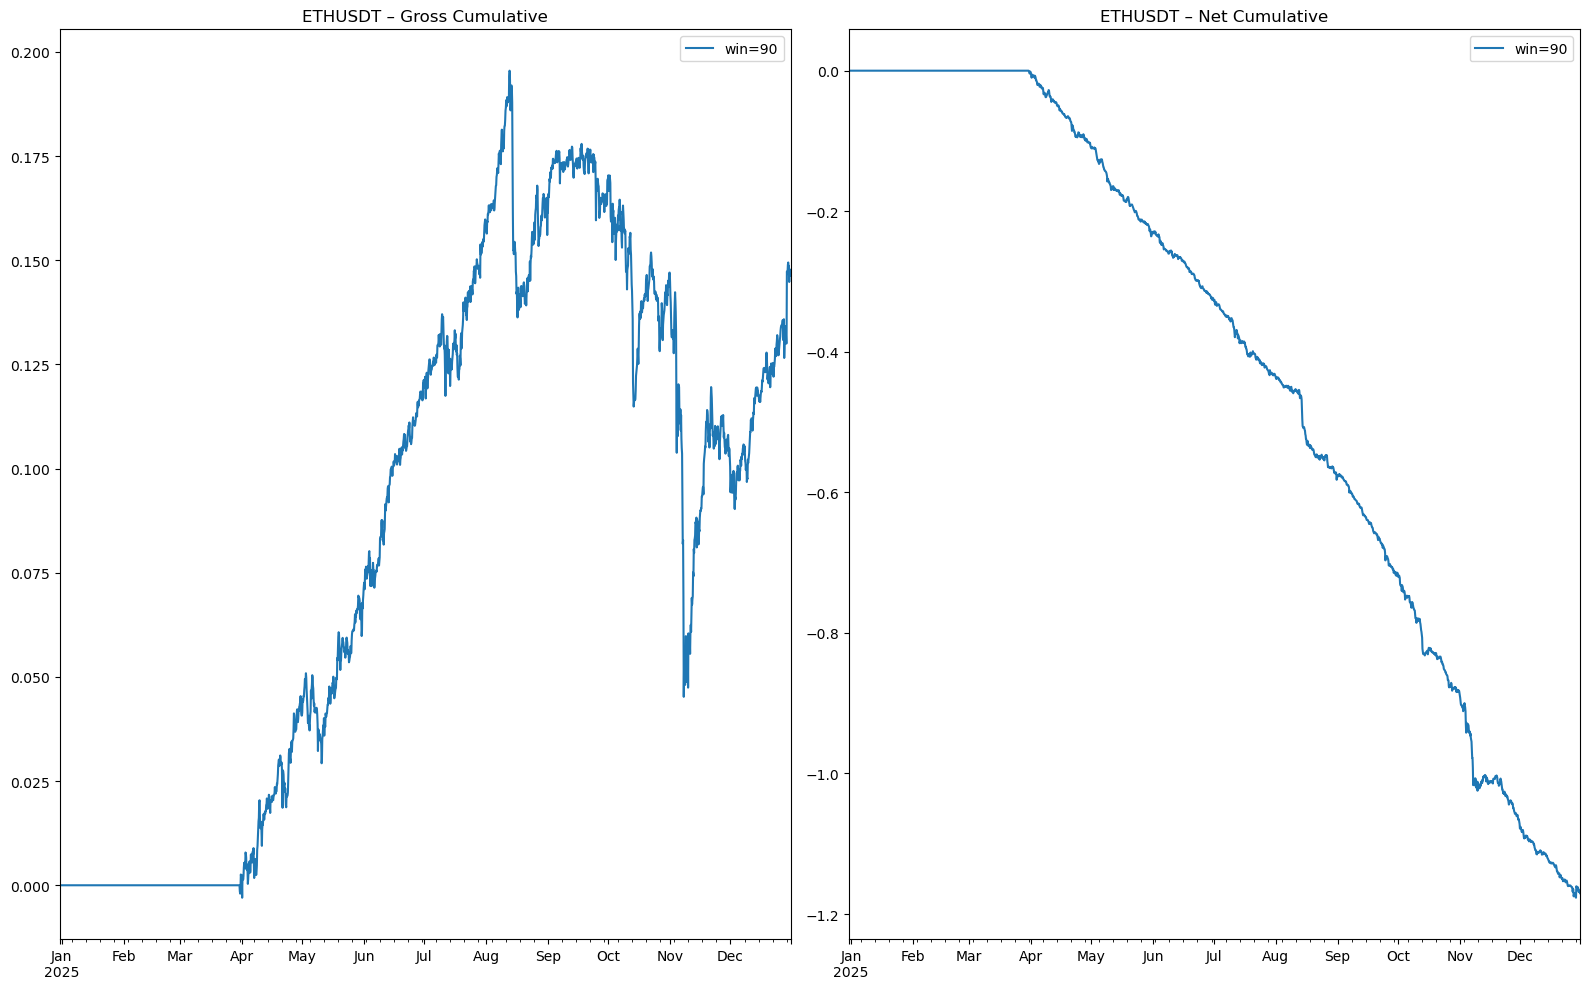

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(16, 10), sharex=True)

label = f"win={int(window_size/(24//strat_time))}"

gross_ret.cumsum().plot(ax=axes[0], label=label)
net_ret.cumsum().plot(ax=axes[1], label=label)

axes[0].set_title(f"{mkt_ticker} – Gross Cumulative")
axes[1].set_title(f"{mkt_ticker} – Net Cumulative")
axes[0].legend()
axes[1].legend()
plt.tight_layout()
plt.show()

In [18]:
to.mean()

0.3004676471924287

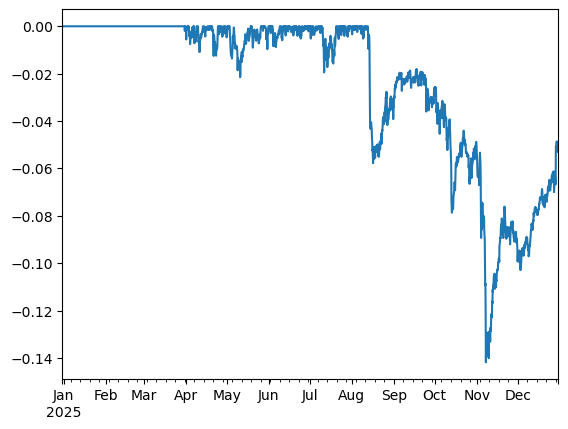

In [20]:
drawdown = stats.drawdown(gross_ret)

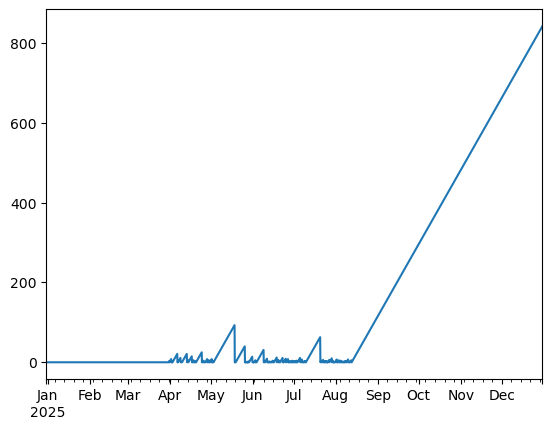

In [21]:
dd = stats.drawdown_duration(gross_ret)